# Day 11 Recap, Resume _About Vectors_ (11 December 2025)

It has been a little over a month since I started my adventure. I am happy because I am busy. I have learned some Python, albeit slowly. I spent some time setting up the blog, but GitHub workflow (Actions) and ChatGPT failed me. I have given up on them and will 

1) Keep doing "core" notebooks (such as this one). They are expected to act like reminders or memory cues. I am applying to my learning what the great mathematician Bill Thurston said of mathematics:
> Mathematics is amazingly compressible: you may struggle a long time, step by step, to work through some process or idea from several approaches. **But once you really understand it and have the mental perspective to see it as a whole, there is often a tremendous mental compression**. You can file it away, recall it quickly and completely when you need it, and use it as just one step in some other mental
process. The insight that goes with this compression is one of the real joys of
mathematics.

1) Keep writing notebooks as blog posts once in a while.

Discussions with ChatGPT have been invaluable. I am still months away from _Thinking in Idiomatic Python_, but I am optimistic about getting there. For now, I am returning to Banesh Hoffmann's book. I will then do Linear Algebra. I will continue exploring Martelli's book and writing [programs](https://github.com/kedarmhaswade/yakk-2/tree/main/programs).

# Chapter 2: Algebraic Notation and Basic Ideas

## 1. Equality and Addition
> Let us agree to say that two vectors, $\vec{U}$ and $\vec{V}$, **are equal if they have equal magnitudes, identical directions, and a common starting point, and represent types of entities that can combine according to the parallelogram law**. If they are _free vectors_ (such as displacement), we need not insist that they have a common starting point:

$$
\begin{equation}
\vec{OA}=\vec{OB}, \text{ or } \vec{\mathbb{U}}=\vec{\mathbb{V}}
\end{equation}
\tag{1.1}
$$

> We shall also use this symbol = in the broader sense of "equivalent to".

> Let us agree to assume that vectors in a given problem or discussion *can combine* unless the contrary is either obvious or else explicitly stated. For example, two displacements can combine, but a force and a displacement cannot.

## Exercise 1.2
If $\vec{\mathbb{U}}$ and $\vec{\mathbb{V}}$ have the same starting point and the same direction, show that the magnitude of their resultant is $\mathbb{U} + \mathbb{V}$.
### Solution 1.2
Showing something can often be challenging in an open area of mathematics. If we assume the axiomatic method, the axioms need to be stated. In a way, we ask ourselves, "Where do I begin?"

I am going to assume Euclidean geometry in space. Therefore, one axiom is that a plane passes through two given vectors. 

Then, we can consider using the Law of Cosines. 

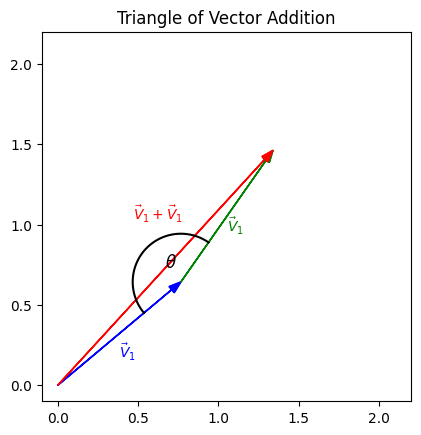

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Two nearly-parallel vectors of equal magnitude
# Let magnitude = 1
angle1 = np.deg2rad(40)    # v1 direction
angle_diff = np.deg2rad(15)  # small difference between the vectors

v1 = np.array([np.cos(angle1), np.sin(angle1)])
v2 = np.array([np.cos(angle1 + angle_diff), np.sin(angle1 + angle_diff)])

# Resultant
R = v1 + v2

# Plot setup
fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')

# Draw v1 (tail at origin)
ax.arrow(0, 0, v1[0], v1[1],
         head_width=0.05, length_includes_head=True, color='blue')

# Draw v2 (tail at head of v1)
ax.arrow(v1[0], v1[1], v2[0], v2[1],
         head_width=0.05, length_includes_head=True, color='green')

# Draw resultant R
ax.arrow(0, 0, R[0], R[1],
         head_width=0.05, length_includes_head=True, color='red')

# Draw v1 from origin
ax.arrow(0, 0, v1[0], v1[1],
         head_width=0.05, length_includes_head=True, color='blue')

# Draw v2 from the head of v1
tail2 = v1
ax.arrow(tail2[0], tail2[1], v2[0], v2[1],
         head_width=0.05, length_includes_head=True, color='green')

# Draw resultant
ax.arrow(0, 0, R[0], R[1],
         head_width=0.05, length_includes_head=True, color='red')

# ---- Angle at the joint: nearly pi radians ----
# Draw arc at tail2 (head of v1)
theta = np.linspace(angle1 + np.pi, angle1 + angle_diff, 200)
arc_radius = 0.3
x_arc = tail2[0] + arc_radius * np.cos(theta)
y_arc = tail2[1] + arc_radius * np.sin(theta)

ax.plot(x_arc, y_arc, color='black')

# Label angle: approx pi - angle_diff
obtuse_angle_deg = 180 - np.rad2deg(angle_diff)
mid_theta = (angle1 + np.pi + (angle1 + angle_diff)) / 2

ax.text(tail2[0] + 0.45 * arc_radius * np.cos(mid_theta),
        tail2[1] + 0.45 * arc_radius * np.sin(mid_theta),
        rf"$\theta$",
        fontsize=12)
# Styling
ax.set_xlim(-0.1, 2.2)
ax.set_ylim(-0.1, 2.2)
ax.set_title("Triangle of Vector Addition")

# Labels
ax.text(v1[0]/2, v1[1]/2 - 0.15, r'$\vec{V}_1$', color='blue')
ax.text(v1[0] + v2[0]/2, v1[1] + v2[1]/2 - 0.1, r'$\vec{V}_1$', color='green')
ax.text(R[0]/2-0.2, R[1]/2 + 0.3, r'$\vec{V}_1 + \vec{V}_1$', color='red')

plt.show()


Now, using the Law of Cosines, we can say that $R^2=V_1^2+V_1^2-2V_1V_1\cos\theta=V_1^2+V_1^2-2V_1^2\cos\theta$.

As $\theta$ approaches $\pi^c$, there is only one value that $R^2$ approaches, and that is $2V_1^2-2V_1^2(\cos\pi)=2V_1^2-2V_1^2(-1)=4V_1^2$

Therefore, $R\to V_1+V_1=2 V_1$. Note that $V_1$ is only a real number (scalar), not a vector. We can use the real number rule, $x+x=2\times x=2x\forall x\in\mathbb{R}$. Thus, the resultant is a vector whose magnitude is twice that of each vector being combined.